In [1]:
from langgraph.graph import StateGraph, MessagesState, START, END
from typing import TypedDict

## State Defination

In [2]:
class TemperatureState(TypedDict):
    temperature_celsius: float
    temperature_fahrenheit: float
    weather_condition: str

## Define and compile the graph

In [3]:
graph = StateGraph(TemperatureState)

## define nodes

In [4]:
def convert_to_fahrenheit(state: TemperatureState) -> TemperatureState:    ## node takse state and retun state as well
   celsius = state.get("temperature_celsius")
   fahrenheit = (celsius * 9/5) + 32
   state["temperature_fahrenheit"] = round(fahrenheit, 2)
   return state

In [5]:
def weather_label(state:TemperatureState)-> TemperatureState:
    fahrenheit = state.get("temperature_fahrenheit")
    if fahrenheit < 32:
        state["weather_condition"] = "Freezing"
    elif fahrenheit < 50:
        state["weather_condition"] = "Cold"
    elif fahrenheit < 70:
        state["weather_condition"] = "Mild"
    elif fahrenheit < 90:
        state["weather_condition"] = "Warm"
    else:
        state["weather_condition"] = "Hot"
    return state

## node connecton to graph

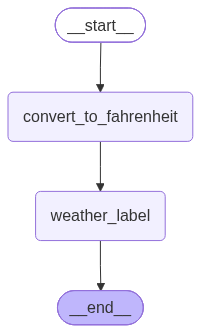

In [6]:
graph.add_node("convert_to_fahrenheit", convert_to_fahrenheit, input_keys=["temperature_celsius"], output_keys=["temperature_fahrenheit"])
graph.add_node("weather_label", weather_label, input_keys=["temperature_fahrenheit"], output_keys=["weather_condition"])

graph.add_edge(START, "convert_to_fahrenheit")
graph.add_edge("convert_to_fahrenheit", "weather_label")
graph.add_edge("weather_label", END)


flow = graph.compile()

flow

## run with example input

In [7]:
result = flow.invoke({"temperature_celsius": 25})
result

{'temperature_celsius': 25,
 'temperature_fahrenheit': 77.0,
 'weather_condition': 'Warm'}